In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

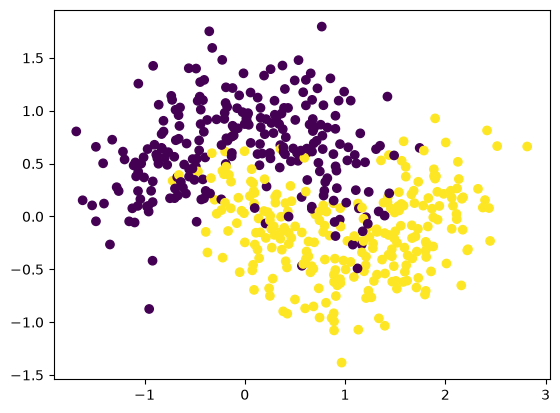

In [20]:
X, y = make_moons(n_samples=500, noise=0.3, random_state=3)
plt.scatter(x = X[:, 0], y = X[:, 1], c=y)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

## Using Default parameters

In [24]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

pred = dt.predict(X_test)

accuracy_score(y_test, pred)

0.88

### `max_depth` : the number of levels in the tree

If max_depth is too low then Underfitting happens and too high then overfits

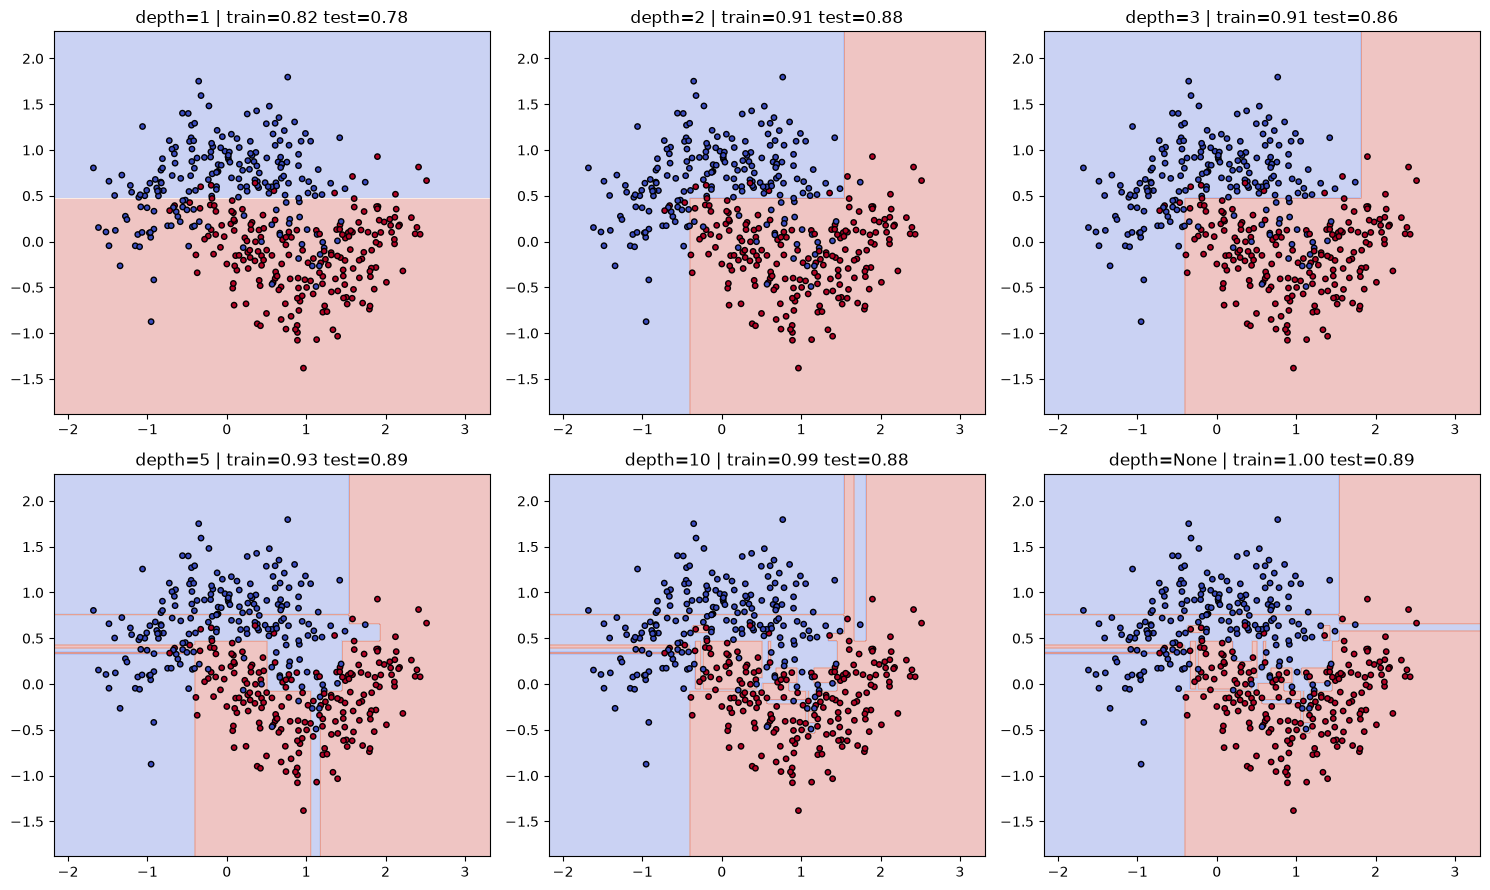

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                      np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))

depths = [1, 2, 3, 5, 10, None]

for ax, depth in zip(axes, depths):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='coolwarm', edgecolor='k', s=15)
    ax.set_title(f"depth={depth} | train={train_acc:.2f} test={test_acc:.2f}")

plt.tight_layout()
plt.show()

## `min_samples_split`

`min_samples_split` sets the minimum number of samples a node must have before it's even allowed to split further.

Default is 2 : meaning a node with just 2 samples can still be split, so the tree can keep growing until leaves are pure (classic overfitting territory).
If you set it higher, e.g. 20, then any node with fewer than 20 samples becomes a leaf immediately

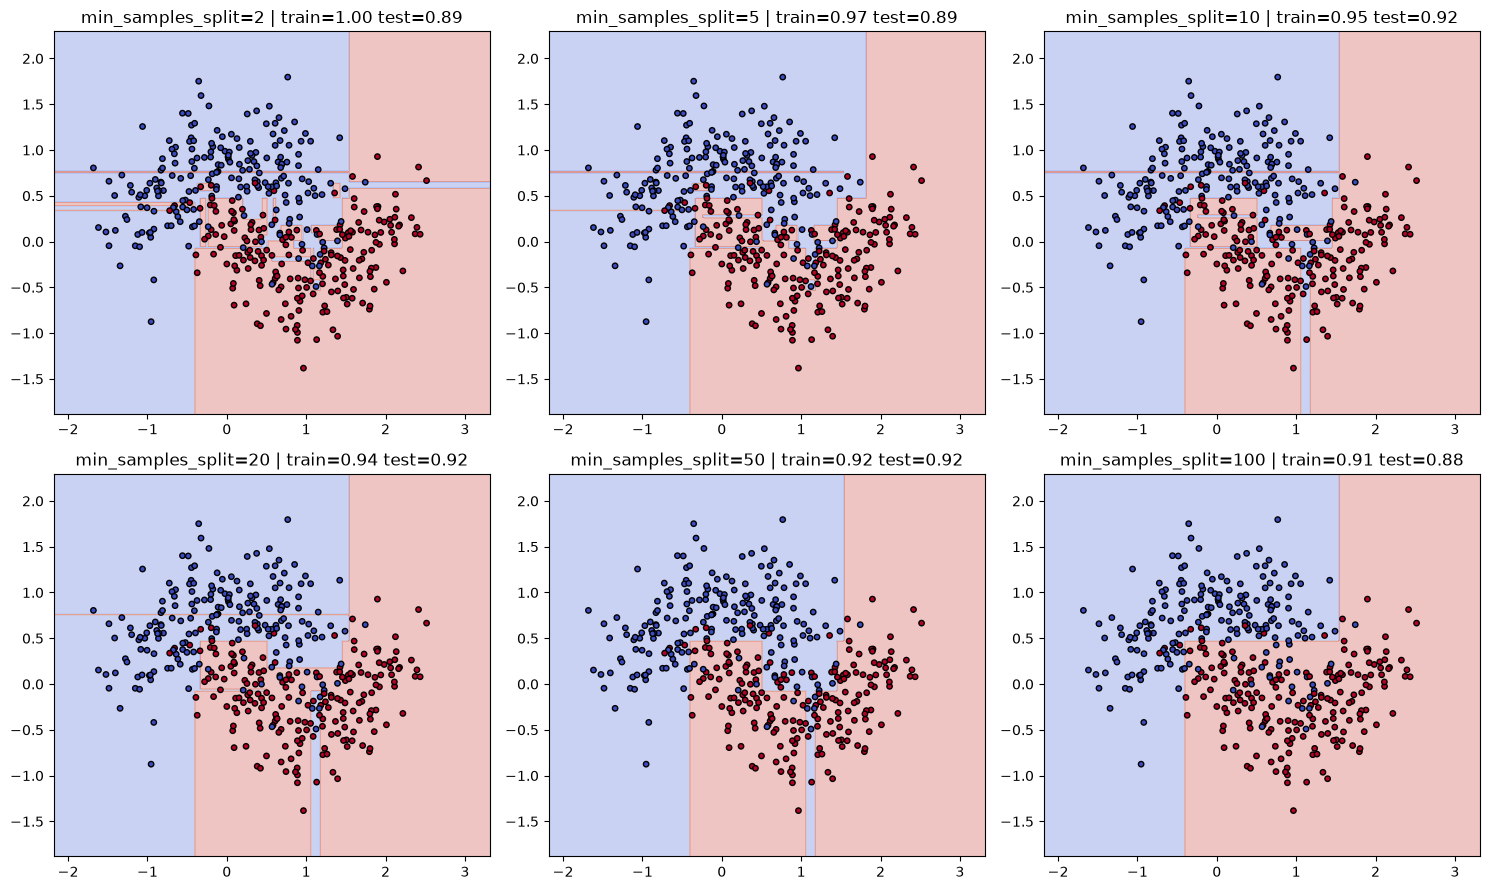

In [31]:
splits = [2, 5, 10, 20, 50, 100]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                      np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))

for ax, split in zip(axes, splits):
    clf = DecisionTreeClassifier(min_samples_split=split, random_state=42)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='coolwarm', edgecolor='k', s=15)
    ax.set_title(f"min_samples_split={split} | train={train_acc:.2f} test={test_acc:.2f}")

plt.tight_layout()
plt.show()

## `min_samples_leaf`

`min_samples_leaf` sets the minimum number of samples that must end up in each child (leaf) node after a split. If a proposed split would leave even one child with fewer samples than this, the split is rejected entirely no matter how good it looks otherwise.

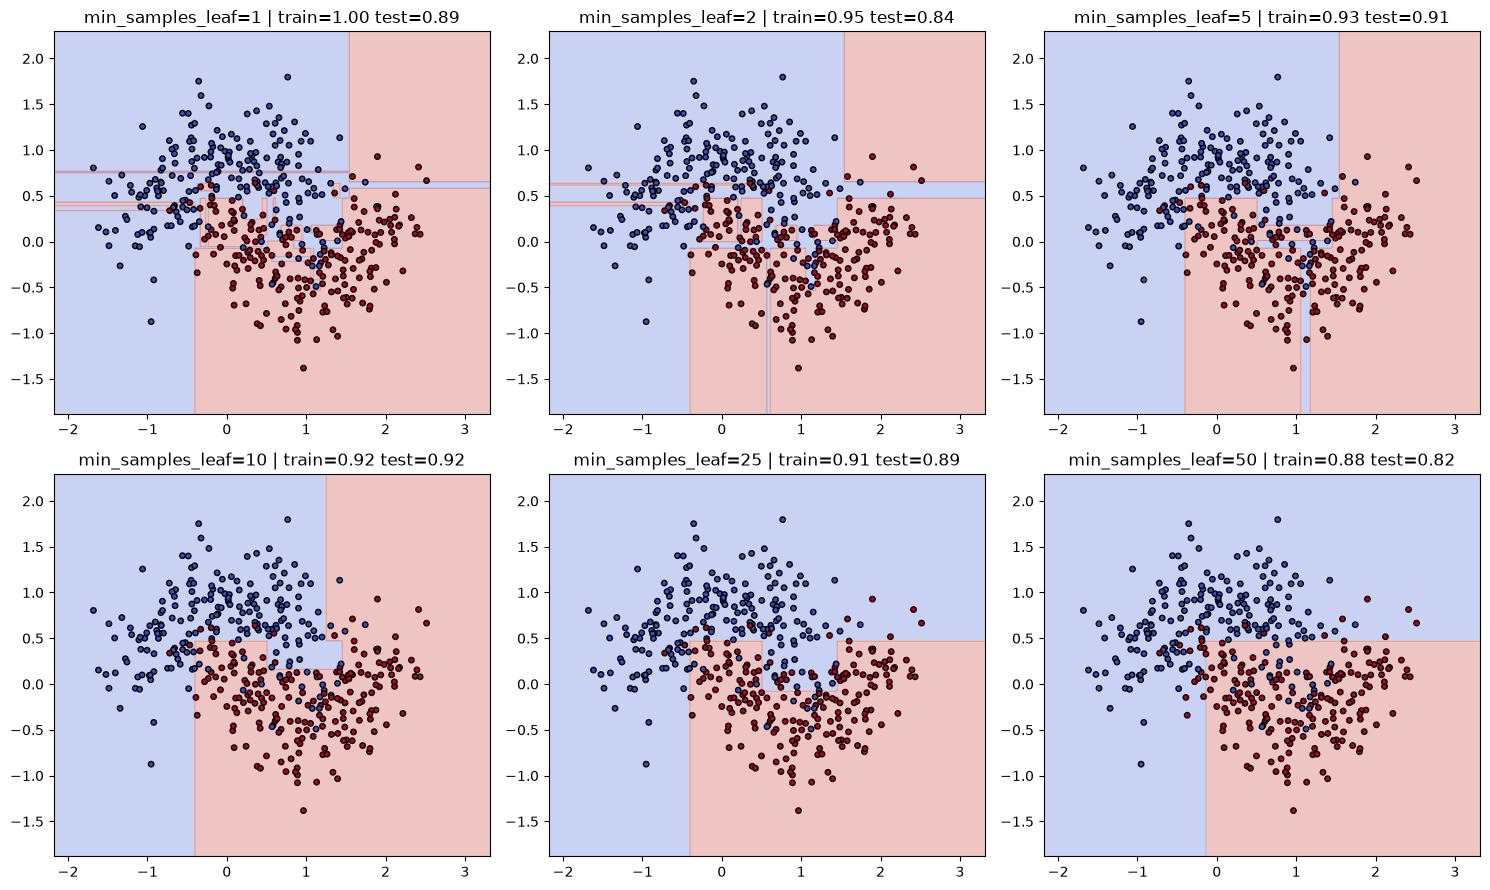

In [30]:
leaves = [1, 2, 5, 10, 25, 50]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                      np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))

for ax, leaf in zip(axes, leaves):
    clf = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='coolwarm', edgecolor='k', s=15)
    ax.set_title(f"min_samples_leaf={leaf} | train={train_acc:.2f} test={test_acc:.2f}")

plt.tight_layout()
plt.show()

## `max_leaf_nodes`

`max_leaf_nodes` caps the total number of leaves the entire tree is allowed to have, full stop. Once the tree hits that limit, it stops splitting anywhere, even if some branches are shallow and could clearly benefit from another split.

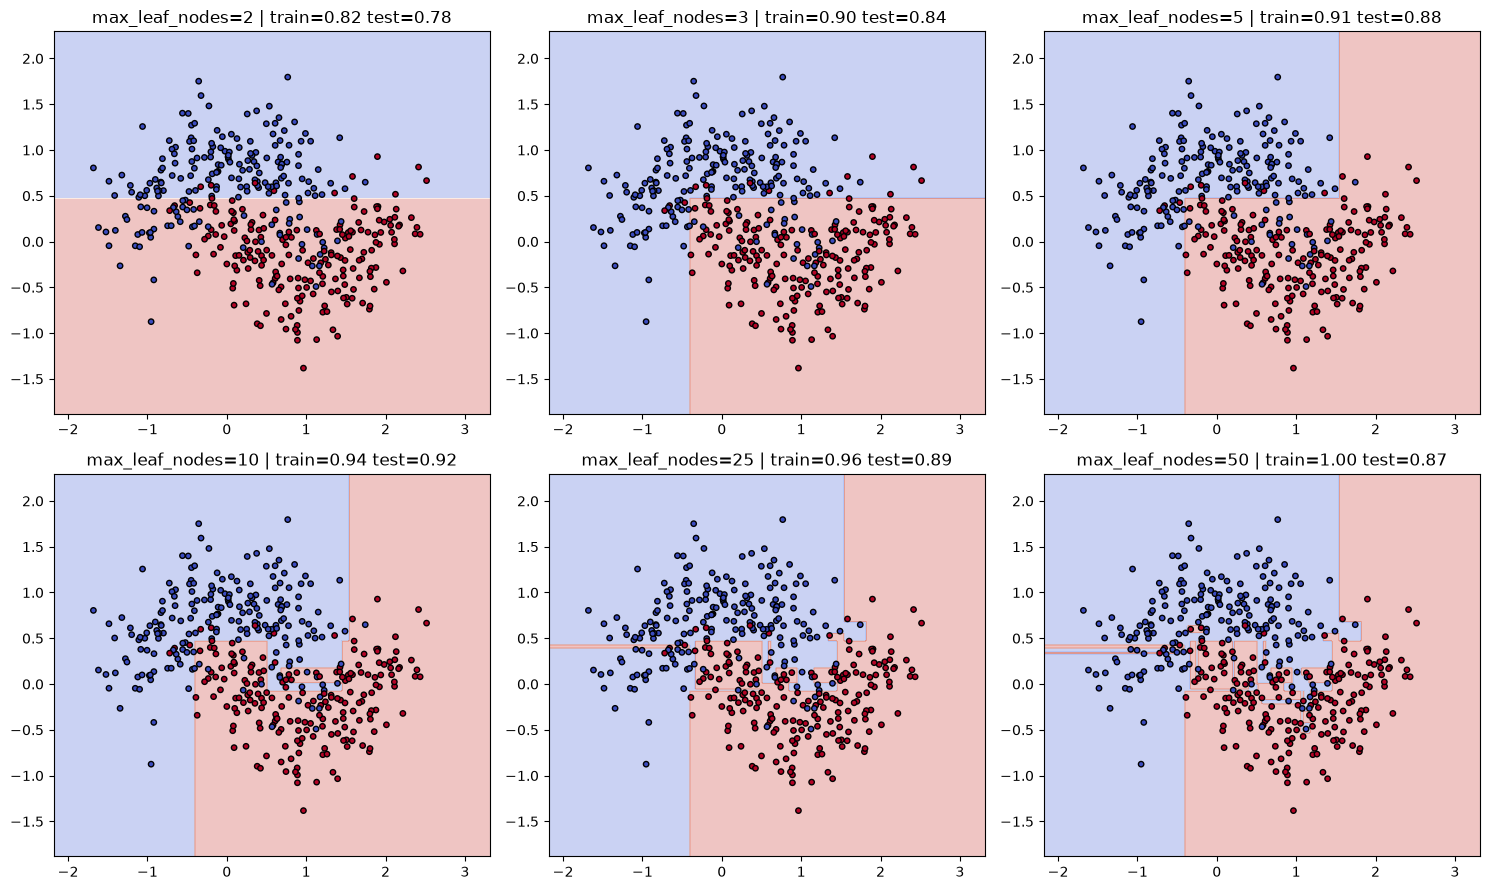

In [32]:
leaf_counts = [2, 3, 5, 10, 25, 50]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                      np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))

for ax, n_leaves in zip(axes, leaf_counts):
    clf = DecisionTreeClassifier(max_leaf_nodes=n_leaves, random_state=42)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='coolwarm', edgecolor='k', s=15)
    ax.set_title(f"max_leaf_nodes={n_leaves} | train={train_acc:.2f} test={test_acc:.2f}")

plt.tight_layout()
plt.show()

## `min_impurity_decrease`

`min_impurity_decrease` sets a minimum threshold on how much a split must reduce impurity (Gini or entropy) before it's allowed to happen. If the best possible split at a node doesn't improve impurity by at least this amount, the node is turned into a leaf instead, even if it's not pure and even if there's plenty of data there to keep splitting.

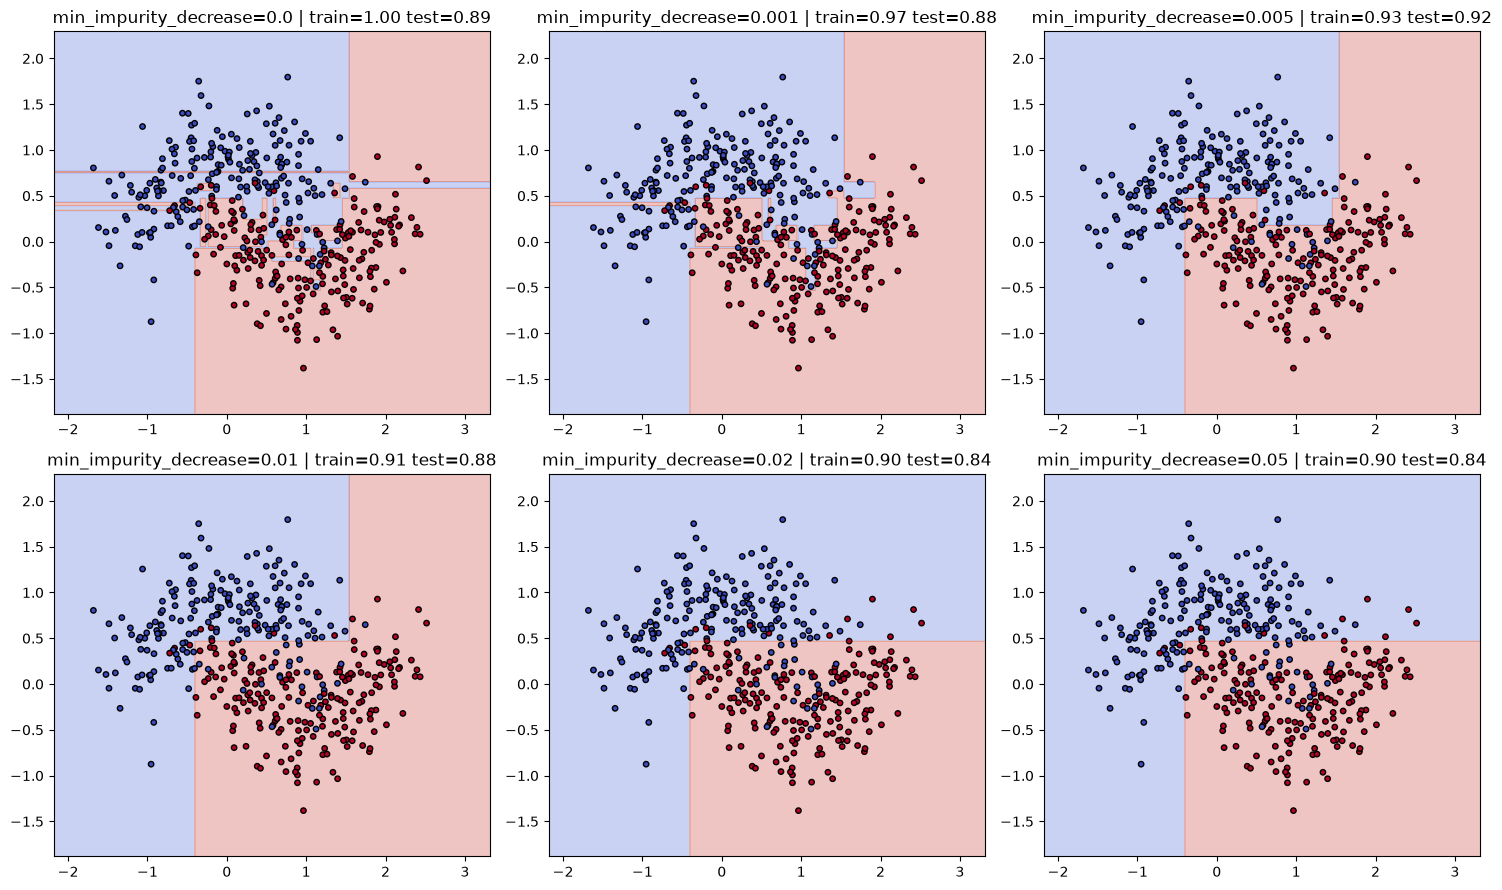

In [33]:
thresholds = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                      np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))

for ax, thresh in zip(axes, thresholds):
    clf = DecisionTreeClassifier(min_impurity_decrease=thresh, random_state=42)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='coolwarm', edgecolor='k', s=15)
    ax.set_title(f"min_impurity_decrease={thresh} | train={train_acc:.2f} test={test_acc:.2f}")

plt.tight_layout()
plt.show()

### Now let's apply the Grid Search to find the best hyperparameters

Fitting 5 folds for each of 960 candidates, totalling 4800 fits
Best params: {'max_depth': 5, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 25, 'min_samples_split': 2}
Best CV accuracy: 0.8850000000000001

Train accuracy: 0.907
Test accuracy:  0.890

               precision    recall  f1-score   support

           0       0.85      0.94      0.89        47
           1       0.94      0.85      0.89        53

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100



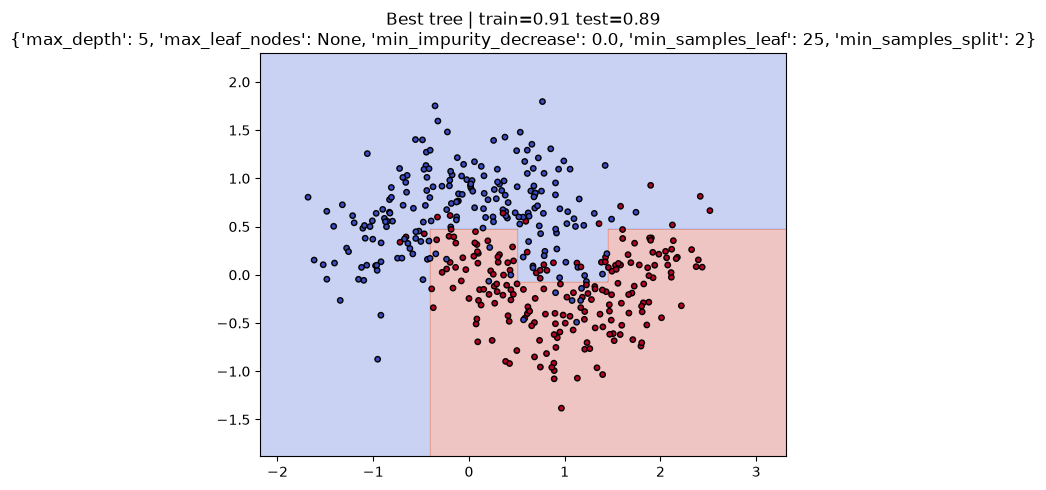

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
param_grid = {
    'max_depth': [2, 3, 5, 10, None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 25],
    'max_leaf_nodes': [None, 10, 25, 50],
    'min_impurity_decrease': [0.0, 0.005, 0.01],
}

# Grid search
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,      # use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best parameters
print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

# Score of best model
best_clf = grid_search.best_estimator_
train_acc = accuracy_score(y_train, best_clf.predict(X_train))
test_acc = accuracy_score(y_test, best_clf.predict(X_test))
print(f"\nTrain accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print("\n", classification_report(y_test, best_clf.predict(X_test)))

# Visualize the best model's decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                      np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))
Z = best_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='coolwarm', edgecolor='k', s=15)
plt.title(f"Best tree | train={train_acc:.2f} test={test_acc:.2f}\n{grid_search.best_params_}")
plt.tight_layout()
plt.show()